In [11]:

import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
import importlib
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from urllib.parse import urlparse
from datetime import datetime, timedelta
import geoquant.configs.config as config
import geoquant.data_io as f1
import geoquant.series_utils as f2
import geoquant.risk_matrix as risk_matrix
import geoquant.books as books
import logging
from geoquant.books import IBKR_live

importlib.reload(books)
importlib.reload(f2)
importlib.reload(config)

logging.getLogger().setLevel(logging.INFO)
print('ok')


ok


In [ ]:

import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
import importlib
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from urllib.parse import urlparse
from datetime import datetime, timedelta
import geoquant.configs.config as config
import geoquant.data_io as f1
import geoquant.series_utils as f2
import geoquant.risk_matrix as risk_matrix
import geoquant.books as books
import logging
from geoquant.books import IBKR_live

importlib.reload(books)
importlib.reload(f2)
importlib.reload(config)

logging.getLogger().setLevel(logging.INFO)
print('ok')


ok


INFO:geoquant.risk_matrix:After alignment only 415 rows remain (expected 617). Data source may not have full history.
INFO:geoquant.risk_matrix:LOOKBACK DAYS/REGIME: 2024-09-01 to 2026-05-11  (617 days)
INFO:geoquant.risk_matrix:++++++ portfolio_risk()


holdings: [{'name': 'XMWX', 'ticker': 'XMWX.LSE', 'ccy': 'GBP', 'USD_exposure': 0.0, 'gbx': False, 'position': 497, 'target_weight': 0.3}, {'name': 'EMIM', 'ticker': 'EMIM.LSE', 'ccy': 'GBP', 'USD_exposure': 0.0, 'gbx': True, 'position': 321, 'target_weight': 0.25}, {'name': 'GWX', 'ticker': 'GWX.US', 'ccy': 'USD', 'USD_exposure': 0.0, 'gbx': False, 'position': 203, 'target_weight': 0.15}, {'name': 'VUAG', 'ticker': 'VUAG.LSE', 'ccy': 'GBP', 'USD_exposure': 1.0, 'gbx': False, 'position': 39, 'target_weight': 0.1}, {'name': 'SGLN', 'ticker': 'SGLN.LSE', 'ccy': 'GBP', 'USD_exposure': 1.0, 'gbx': True, 'position': 68, 'target_weight': 0.08}, {'name': 'BATG', 'ticker': 'BATG.LSE', 'ccy': 'GBP', 'USD_exposure': 0.34, 'gbx': True, 'position': 173, 'target_weight': 0.12}, {'name': 'CASH_CHF', 'type': 'cash', 'ccy': 'CHF', 'amount': 11953, 'target_weight': 0.0}, {'name': 'CASH_JPY', 'ticker': 'JPYCHF.FOREX', 'type': 'cash', 'ccy': 'JPY', 'amount': 11416, 'target_weight': 0.0}, {'name': 'CASH_G

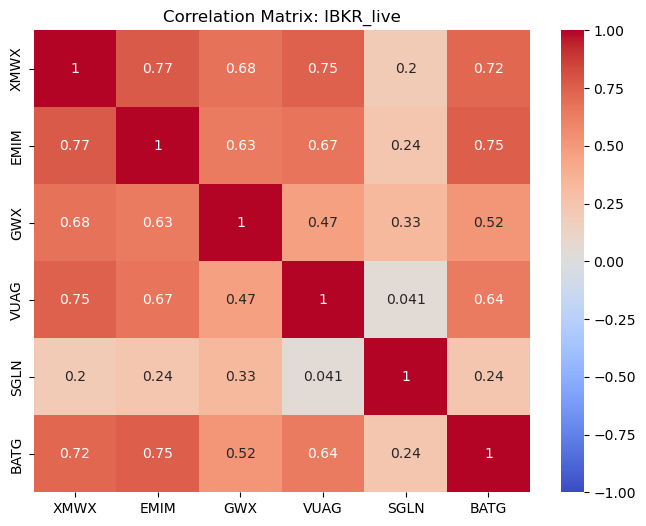

In [12]:

# PORTFOLIO = 'IBKR_live' 
holdings = books.IBKR_live    
# holdings=getattr(books, PORTFOLIO)  # verify it exists

print('holdings:', holdings)

data_params = config.data_params
print('data_params:', data_params)
DEBUG = False
print('------\nBOOK:', 'IBKR_live', '\n-------')
max_age = data_params.get('max_age', 0)
print('max_age (hrs):', max_age, '\n-------')

rets_df, prices_df, w = risk_matrix.build_returns_weights(holdings, data_params=config.data_params, no_fx=False, usd_shift=False)

risk = risk_matrix.portfolio_risk(rets_df, w)

# print( rets_df.tail(3) )
print("------------\nPortfolio σ (an_adjnualized, CHF): {:.2%}".format(risk["port_vol"]))
print(" CORE EQUITY BAND = 15 - 30%, DIVERSIFIERS = 5 - 12%, TACTICALS <= 10%,")
print('equity core max 30%, diversifiers max 12%, tacticals max 10%, total max 15%')
print('RISK ["SUMMARY"]:')
print(risk["summary"].round({"Weight":3,"Vol_1Y_CHF":3,"MRC":3,"PRC_%":1, }))
print(f'CORRELATION:')
print(f'{risk["corr"].round(2)}')
print(f'COVARIANCE:')
print(f'{risk["cov_annual"]}')

corr_matrix = risk["corr"]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title(f"Correlation Matrix: {PORTFOLIO}")
plt.show()

In [4]:
def eod_search(quey: str, token: str):
    import requests, pandas as pd
    url = f"https://eodhd.com/api/search/{quey}?api_token={token}&fmt=json"
    r = requests.get(url, timeout=30); r.raise_for_status()
    hits = r.json()
    # Return a small table to pick from
    return pd.DataFrame([{
        "code": h.get("Code"),
        "exchange": h.get("Exchange"),
        "name": h.get("Name"),
        "currency": h.get("Currency"),
        "type": h.get("Type"),
        "startdate": h.get("StartDate"),
        # earliet date

    } for h in hits])

# Usage:
df = eod_search("litg", config.EOD_API)
# pick the line with the longest available history (often XETRA/LSE/SIX)
print(df)

AttributeError: module 'geoquant.configs.config' has no attribute 'EOD_API'

## GET THE EARLIEST DATE ##

In [ ]:
START = '2020-01-02'
ticker = 'XMWX.LSE'


# Fetch EODHD daily FX and build a Series
fx_df = f1.fetch_csv_robust(ticker, data_params=config.data_params)
print(fx_df.head(1))

XMWX.LSE - downloading fresh data
XMWX.LSE - cleaned 2 flat-bar spike(s) on download
data start date b4 saving: 2024-08-27
               Open     High      Low    Close  Adjusted_close  Volume
Date                                                                  
2024-08-27  33.1258  33.1258  33.1258  33.1258         33.1258       0


## Equity correlation drift check
We’ll:
- compute a 60-day rolling average pairwise correlation across the equity ETFs in your `rets_df`.
- show the 1-year view you’re using now (limited by `XMWX`).
- also compute a 3-year view excluding `XMWX` (if data exist), to see whether the increase is structural or just recent.

In [5]:
# 1) Current 1-year view (already in rets_df)
# Pick equity ETFs present in rets_df
all_cols = list(rets_df.columns)
EQUITY_LIKE = [c for c in ["EMIM","GWX","BATG","XMWX","SGLN", 'YCA'] if c in all_cols]

if len(EQUITY_LIKE) >= 2:
    rets_eq_1y = rets_df[EQUITY_LIKE]
    # 60D rolling average of pairwise correlation (off-diagonal mean)
    def offdiag_mean(corr_m):
        if corr_m.shape[0] < 2:
            return np.nan
        n = corr_m.shape[0]
        return (corr_m.values.sum() - n) / (n*(n-1))

    roll_avg_corr_1y = (
        rets_eq_1y.rolling(60).corr().groupby(level=0).apply(lambda c: offdiag_mean(c))
    )

    print("1Y rolling(60) avg pairwise equity corr (tail):")
    print(roll_avg_corr_1y.dropna().tail(10))
else:
    print("Not enough equity-like tickers to compute 1Y pairwise correlation.")

# 2) Longer 3Y view excluding XMWX (if data available): re-fetch or extend window is out of scope here,
# but we can approximate by checking if older data exist in prices_df; if not, we demonstrate exclusion-only.
try:
    # If you want to explicitly exclude XMWX to avoid its shorter history limiting the window
    EQUITY_NO_XMWX = [c for c in EQUITY_LIKE if c != "XMWX"]
    if len(EQUITY_NO_XMWX) >= 2:
        # Use available rets_df (1Y). For a true 3Y view, rerun 
        rets_eq_ex = rets_df[EQUITY_NO_XMWX]
        roll_avg_corr_ex = (
            rets_eq_ex.rolling(60).corr().groupby(level=0).apply(lambda c: offdiag_mean(c))
        )
        print("Ex-XMWX rolling(60) avg pairwise equity corr (tail):")
        print(roll_avg_corr_ex.dropna().tail(756))
    else:
        print("Not enough non-XMWX equity-like tickers to compute ex-XMWX correlation.")
except Exception as e:
    print("Correlation analysis note:", e)


1Y rolling(60) avg pairwise equity corr (tail):
Date
2026-04-23    0.486743
2026-04-24    0.485983
2026-04-27    0.499019
2026-04-28    0.498753
2026-04-29    0.497419
2026-04-30    0.504665
2026-05-01    0.508668
2026-05-05    0.504667
2026-05-06    0.505549
2026-05-07    0.502728
dtype: float64
Ex-XMWX rolling(60) avg pairwise equity corr (tail):
Date
2024-11-26    0.398901
2024-11-27    0.395797
2024-11-29    0.397309
2024-12-02    0.369931
2024-12-03    0.362244
                ...   
2026-04-30    0.607414
2026-05-01    0.610228
2026-05-05    0.603967
2026-05-06    0.603452
2026-05-07    0.599602
Length: 354, dtype: float64
